<a href="https://colab.research.google.com/github/barakatokikiola/Colab_AI_Exercises/blob/main/MNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Initializing Deep Learning Model for MNIST ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Starting Training Phase ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9089 - loss: 0.3149 - val_accuracy: 0.9623 - val_loss: 0.1241
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9556 - loss: 0.1516 - val_accuracy: 0.9730 - val_loss: 0.0939
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9661 - loss: 0.1131 - val_accuracy: 0.9760 - val_loss: 0.0830
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9708 - loss: 0.0934 - val_accuracy: 0.9778 - val_loss: 0.0736
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9753 - loss: 0.0792 - val_accuracy: 0.9807 - val_loss: 0.0711

--- Evaluating Model on Test Data ---
313/313 - 1s - 2ms/step - accuracy: 0.9762 - loss: 0.0751

Final Test Accuracy: 0.9762

--- Visualizing Predictions ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


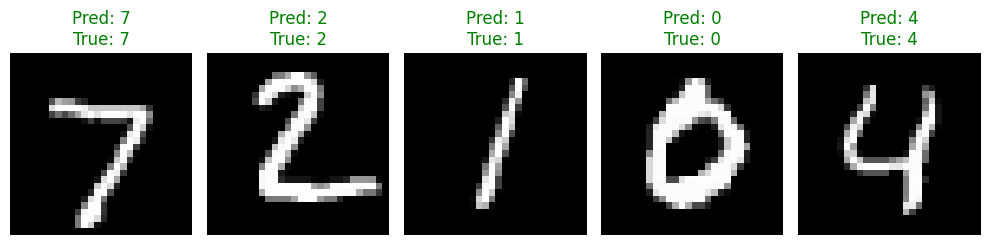

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import numpy as np

print("--- Initializing Deep Learning Model for MNIST ---")

# Step 1: Load the dataset
# MNIST is built directly into Keras, so we don't need external CSVs
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Step 2: Preprocess the data
# Pixel values range from 0 to 255. Neural networks learn better when data is scaled.
# We normalize the data to sit strictly between 0 and 1.
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 3: Build the Model Architecture
model = Sequential([
    # Input Layer: Flatten the 28x28 2D image array into a 1D array of 784 pixels
    Flatten(input_shape=(28, 28)),

    # Hidden Layer: 128 nodes with ReLU activation
    Dense(128, activation='relu'),

    # Regularization: Randomly drop 20% of nodes during training to prevent overfitting
    Dropout(0.2),

    # Output Layer: 10 nodes (one for each possible digit 0-9)
    # Softmax outputs a probability distribution across all 10 classes
    Dense(10, activation='softmax')
])

# Step 4: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train the Model
print("\n--- Starting Training Phase ---")
# We train for 5 epochs (5 passes through the entire training dataset)
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

# Step 6: Evaluate on Unseen Test Data
print("\n--- Evaluating Model on Test Data ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Step 7: Make Predictions and Visualize Results
print("\n--- Visualizing Predictions ---")
predictions = model.predict(X_test)

# Plot the first 5 images in the test set alongside their predicted labels
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')

    # np.argmax gets the index of the highest probability in the output array
    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]

    # Color the title green if correct, red if wrong
    color = 'green' if predicted_label == actual_label else 'red'
    plt.title(f"Pred: {predicted_label}\nTrue: {actual_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()